1) import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


2) Load Dataset

In [2]:
df = pd.read_csv("raw_wholesale_customers.csv")  # change path if needed
print("Dataset loaded.")
display(df.head())
print(df.info())

Dataset loaded.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None


3) Select Features + IQR Capping

In [3]:
features = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"]
X = df[features].copy()

for col in features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X[col] = X[col].clip(lower, upper)

print("IQR capping completed.")
display(X.head())

IQR capping completed.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669.0,9656.0,7561.0,214.0,2674.0,1338.00
1,7057.0,9810.0,9568.0,1762.0,3293.0,1776.00
2,6353.0,8808.0,7684.0,2405.0,3516.0,3938.25
3,13265.0,1196.0,4221.0,6404.0,507.0,1788.00
4,22615.0,5410.0,7198.0,3915.0,1777.0,3938.25


4) Scale Features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling completed.")
print(X_scaled[:5])

Scaling completed.
[[ 0.12857261  1.05158597  0.04926747 -0.95324427  0.09579175  0.06589216]
 [-0.42162716  1.08673463  0.35386453 -0.30973493  0.30651872  0.47075856]
 [-0.49064723  0.85804007  0.06793486 -0.04243744  0.38243489  2.46943983]
 [ 0.18700437 -0.87930823 -0.45763545  1.61996169 -0.64192284  0.48185079]
 [ 1.10367719  0.08248706 -0.00582407  0.58527516 -0.20957511  2.46943983]]


5)  Elbow Method

k=1: SSE=2640.00
k=2: SSE=1728.19
k=3: SSE=1363.45
k=4: SSE=1202.41
k=5: SSE=1070.15
k=6: SSE=964.76
k=7: SSE=921.14
k=8: SSE=776.63
k=9: SSE=726.88
k=10: SSE=707.41


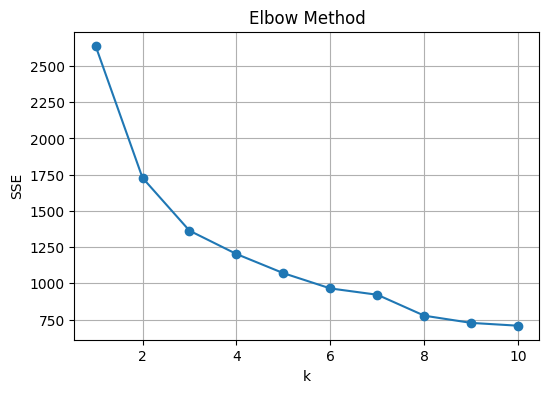

In [5]:
sse = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    sse.append(km.inertia_)
    print(f"k={k}: SSE={km.inertia_:.2f}")

plt.figure(figsize=(6,4))
plt.plot(range(1,11), sse, marker="o")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

6) Train K-Means

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)
print("K-Means trained.")
display(df.head())

K-Means trained.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,KMeans_Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,3


7) Evaluate K-Means

In [7]:
sil = silhouette_score(X_scaled, df["KMeans_Cluster"])
db = davies_bouldin_score(X_scaled, df["KMeans_Cluster"])

print("Silhouette Score:", sil)
print("Davies-Bouldin Index:", db)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)
print("\nCluster Centers (Original Units)")
display(centers_df)

Silhouette Score: 0.28305439449159625
Davies-Bouldin Index: 1.270058546306858

Cluster Centers (Original Units)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9202.671053,6833.302632,9104.118421,1326.157895,3280.118421,1871.756579
1,8376.230366,2150.649215,3160.628272,1646.329843,779.251309,674.015707
2,17461.540000,13805.605000,17524.120000,4120.570000,5460.565000,3583.640000
3,22346.698864,3409.137784,3969.329545,5819.596591,583.068182,1566.946023
4,4916.983333,10768.854167,18350.133333,1212.366667,7780.018750,981.366667


8) Second Clustering Algorithm
Algorithm: Agglomerative (Hierarchical) Clustering

I selected Agglomerative Clustering because it groups customers based on similarity without requiring centroid updates. It is useful for customer segmentation because it can reveal hierarchical relationships among customer groups.

Source: https://scikit-learn.org/stable/modules/clustering.html

9) Train Agglomerative Clustering

In [8]:
agg = AgglomerativeClustering(n_clusters=5)
df["Agglomerative_Cluster"] = agg.fit_predict(X_scaled)

agg_sil = silhouette_score(X_scaled, df["Agglomerative_Cluster"])

print("Agglomerative Silhouette Score:", agg_sil)

Agglomerative Silhouette Score: 0.21848258044114816


10) Compare Methods

In [9]:
print("K-Means Silhouette Score:", sil)
print("Agglomerative Silhouette Score:", agg_sil)

if sil > agg_sil:
    print("K-Means produced better-separated clusters.")
elif agg_sil > sil:
    print("Agglomerative produced better-separated clusters.")
else:
    print("Both methods produced similar separation.")

K-Means Silhouette Score: 0.28305439449159625
Agglomerative Silhouette Score: 0.21848258044114816
K-Means produced better-separated clusters.


11) Sanity Check

In [10]:
sample = df.sample(3, random_state=42)

cols = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen","Channel","Region","KMeans_Cluster","Agglomerative_Cluster"]

display(sample[cols])

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel,Region,KMeans_Cluster,Agglomerative_Cluster
265,5909,23527,13699,10155,830,3636,1,1,2,0
78,10766,1175,2067,2096,301,167,1,3,1,2
347,27380,7184,12311,2809,4621,1022,2,3,0,0


12) Save Output

In [11]:
df.to_csv("segmented_wholesale_customers.csv", index=False)
print("Saved as segmented_wholesale_customers.csv")

Saved as segmented_wholesale_customers.csv
